In [1]:
# Dependencies
import sys
import os
import signal

print("Installing dependencies...")

# 1. Install dependencies
#    Added: bitsandbytes (for 4-bit quantization to fit Giga on T4/A100)
#    Added: accelerate (required for device_map="auto")
#    Added: autoawq (for running AWQ quantized LLMs in Phase 3)
!{sys.executable} -m pip install -q "numpy<2.0" qdrant-client sentence-transformers FlagEmbedding matplotlib scikit-learn pandas requests tqdm einops pyarrow accelerate ipywidgets datasets bitsandbytes autoawq

# 2. Check imports to see if a Restart is required
try:
    import numpy as np
    import pandas as pd
    import bitsandbytes
    print(f"Numpy Version: {np.__version__}")
    print(f"Pandas Version: {pd.__version__}")

    # Simple check: If we can't create a DataFrame, we are doomed and must restart.
    df_test = pd.DataFrame({"a": [1, 2, 3]})
    print("Dependency Check Passed.")

except Exception as e:
    print(f"Dependency Mismatch Detected ({e}). Restarting Kernel automatically...")
    # Restart the environment
    os.kill(os.getpid(), 9)

import torch
if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    print(f"\nGPU Available: {props.name}")
    print(f"   VRAM: {props.total_memory / 1024**3:.2f} GB")
    print(f"   CUDA Capabilities: {props.major}.{props.minor}")

    if props.total_memory / 1024**3 < 20:
        print("WARNING: You are running on a GPU with < 20GB VRAM (likely T4).")
        print("   The 'Giga' model naturally requires ~30GB+ or ~15GB in FP16.")
        print("   We will attempt to load it in 4-bit mode to fit.")
else:
    print("\nNo GPU detected. This benchmark is designed for T4/A100/H100 GPUs.")
    print("   If you have allocated a GPU, please check 'Runtime > Change runtime type'.")

Installing dependencies...
Numpy Version: 1.26.4
Pandas Version: 2.2.2
Dependency Check Passed.

GPU Available: NVIDIA A100-SXM4-40GB
   VRAM: 39.56 GB
   CUDA Capabilities: 8.0


In [ ]:
# Data Pipeline (Corrected for Train/Test Split)
import json
import os
import pandas as pd
from tqdm.auto import tqdm
from typing import List, Dict

# Define Paths
TRAIN_PATH = "data/train.jsonl"
TEST_PATH = "data/test.jsonl" 

# Helper to load data
def load_data(filepath, desc):
    data = []
    if os.path.exists(filepath):
        print(f"Reading from: {filepath}")
        with open(filepath, 'r', encoding='utf-8') as f:
            for i, line in tqdm(enumerate(f), desc=desc):
                if not line.strip(): continue
                try:
                    row = json.loads(line)
                    inp = row.get('input') or row.get('question')
                    out = row.get('output') or row.get('answer')
                    if inp and out:
                        # Create unique ID based on file and line to avoid collisions
                        data.append({"id": f"{os.path.basename(filepath)}_{i}", "input": inp, "output": out})
                except: continue
    return data

print("Searching for datasets...")

# 1. Load Knowledge Base (Train)
docs_kb = load_data(TRAIN_PATH, "Loading Knowledge Base")
if not docs_kb:
    # Fallback to local train.jsonl in root if data folder is empty
    if os.path.exists("train.jsonl"):
        docs_kb = load_data("train.jsonl", "Loading Local Train")
    
if not docs_kb:
    raise FileNotFoundError(f"Could not find training data at {TRAIN_PATH} or ./train.jsonl")

# 2. Load Test Queries
docs_test = load_data(TEST_PATH, "Loading Test Set")

# 3. Fallback: Split Strategy if Test is missing
if not docs_test:
    print("WARNING: 'test.jsonl' not found. Performing 90/10 Split on Train data.")
    split_idx = int(len(docs_kb) * 0.9)
    docs_test = docs_kb[split_idx:] # Last 10%
    docs_kb = docs_kb[:split_idx]   # First 90%
    print(f"   Split Result: {len(docs_kb)} for Index, {len(docs_test)} for Testing.")
else:
    print(f"   Loaded Explicit Test Set: {len(docs_test)} queries.")

print(f"\nDATA READY: {len(docs_kb)} docs for Indexing | {len(docs_test)} docs for Querying.")

Searching for dataset...
Found in data folder: sample_data/train.jsonl
Reading from: sample_data/train.jsonl


Reading JSONL: 0it [00:00, ?it/s]

Loaded 21325 documents from local file.

DATA READY: 21325 documents prepared for benchmarking.


In [3]:
# The Benchmark Class (Updated for Persistence)
from qdrant_client import QdrantClient
from qdrant_client.models import Distance, VectorParams, PointStruct
from sentence_transformers import SentenceTransformer
from tqdm.auto import tqdm
import uuid
import torch
import numpy as np
import os
from typing import List, Dict

class RAGExperiment:
    def __init__(self, model_id: str):
        # FORCE GPU if available, otherwise WARN
        if torch.cuda.is_available():
            self.device = "cuda"
            props = torch.cuda.get_device_properties(0)
            print(f"GPU Mode Active: {props.name}")
            try:
                # Enable TF32 for Ampere (A100) and Hopper (H100) GPUs for significant speedup
                torch.set_float32_matmul_precision('high')
                print("   TF32 Precision Enabled (H100/A100 optimization)")
            except:
                pass
        else:
            self.device = "cpu"
            print(" CPU Mode Active (WARNING: Slower execution)")

        self.model_id = model_id
        # sanitize model name for folder usage
        self.safe_name = model_id.replace("/", "_")
        self.model_name = model_id

        print(f" Initializing Model: {model_id} on {self.device}")

        # Load Model
        self.encoder = SentenceTransformer(model_id, device=self.device, trust_remote_code=True)

        # CHANGED: Use Disk Storage instead of RAM (:memory:)
        # This saves the vectors to a folder so we don't have to re-index every time
        self.storage_path = f"qdrant_storage_{self.safe_name}"
        self.client = QdrantClient(path=self.storage_path)
        self.collection_name = "benchmark_collection"

        print(f"   Vector Database persisted at: ./{self.storage_path}")

    def index(self, documents: List[Dict], batch_size: int = 64):
        # CHECK: If collection exists and has items, SKIP indexing
        try:
            count = self.client.count(self.collection_name).count
            if count > 0:
                print(f"   CACHE HIT: Found {count} documents already indexed in '{self.storage_path}'. Skipping Step.")
                return
        except:
            pass # Collection doesn't exist, proceed to create

        print(f"Indexing {len(documents)} documents (This happens only once)...")

        # Determine Vector Size
        sample_vec = self.encoder.encode(["test"], show_progress_bar=False)
        if hasattr(sample_vec, "tolist"):
             sample_vec = sample_vec[0]
        else:
             sample_vec = sample_vec[0]

        vector_size = len(sample_vec)

        self.client.recreate_collection(
            collection_name=self.collection_name,
            vectors_config=VectorParams(size=vector_size, distance=Distance.COSINE)
        )

        # Batch Upsert
        points = []
        for i in tqdm(range(0, len(documents), batch_size), desc="Indexing"):
            batch = documents[i : i+batch_size]
            texts = [str(d['output']) for d in batch]

            # Encode on GPU
            vectors = self.encoder.encode(texts, batch_size=batch_size, show_progress_bar=False, convert_to_numpy=True)

            for j, doc in enumerate(batch):
                point_id = str(uuid.uuid5(uuid.NAMESPACE_DNS, str(doc['id'])))
                points.append(PointStruct(id=point_id, vector=vectors[j].tolist(), payload=doc))

            self.client.upsert(self.collection_name, points)
            points = []

    def retrieve(self, query: str, top_k: int = 5):
        query_vector = self.encoder.encode([query], show_progress_bar=False)[0]

        try:
            hits = self.client.query_points(
                self.collection_name,
                query=query_vector,
                limit=top_k
            ).points
        except (AttributeError, TypeError):
            hits = self.client.search(
                self.collection_name,
                query_vector=query_vector,
                limit=top_k
            )

        return hits

In [ ]:
# Experiment Phase 1 (Embedding Battle)
from sklearn.metrics import ndcg_score
from sentence_transformers import util
from tqdm.auto import tqdm
import gc

# --- Settings for H100 Benchmarking ---
DOC_LIMIT = 20000   
QUERY_LIMIT = 2000  
TOP_K = 3

subset_docs = docs_kb[:DOC_LIMIT]
subset_queries = docs_test[:QUERY_LIMIT]

print(f"Starting H100 Benchmark with:")
print(f"   Knowledge Base: {len(subset_docs)} docs")
print(f"   Test Queries:   {len(subset_queries)} queries")

results = {}

def calculate_metrics(hits, expected_text, model=None):
    retrieved_texts = [h.payload['output'] for h in hits]
    target = expected_text.strip()
    
    relevance = []

    # 1. OPTIMIZATION: Try Exact Match first (Fastest)
    exact_matches = [1 if txt.strip() == target else 0 for txt in retrieved_texts]
    
    if sum(exact_matches) > 0:
        relevance = exact_matches
    
    # 2. SEMANTIC CHECK: If no exact match, check meaning with embeddings
    elif model is not None:
        # Encode quickly without progress bar
        emb_target = model.encode(target, convert_to_tensor=True, show_progress_bar=False)
        emb_retrieved = model.encode(retrieved_texts, convert_to_tensor=True, show_progress_bar=False)
        
        # Calculate Cosine Similarity
        cos_scores = util.cos_sim(emb_target, emb_retrieved)[0] # List of scores
        
        # Soft Threshold: 0.85 means "Very similar meaning"
        SIMILARITY_THRESHOLD = 0.85
        relevance = [1 if score > SIMILARITY_THRESHOLD else 0 for score in cos_scores]
        
    else:
        # Fallback if no model provided
        relevance = exact_matches

    # Recall
    recall = 1 if sum(relevance) > 0 else 0

    # MRR
    mrr = 0.0
    for rank, is_rel in enumerate(relevance, start=1):
        if is_rel:
            mrr = 1.0 / rank
            break

    # NDCG
    if sum(relevance) == 0:
        ndcg = 0.0
    else:
        ideal = sorted(relevance, reverse=True)
        ndcg = ndcg_score([ideal], [relevance])

    return recall, mrr, ndcg

MODELS = [
    "infgrad/stella-base-en-v2",       # Fast Baseline
    "ai-sage/Giga-Embeddings-instruct" # SOTA Heavyweight
]

best_model_instance = None
best_mrr_score = -1.0

for model_name in MODELS:
    # Cleanup
    if 'exp' in locals() and exp is not None:
        if hasattr(exp, 'encoder') and exp.encoder is not None:
             del exp.encoder
        del exp
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    gc.collect()

    try:
        exp = RAGExperiment(model_name)
        
        # Batch Size Logic
        current_batch_size = 128
        if "Giga" in model_name: current_batch_size = 16 

        exp.index(subset_docs, batch_size=current_batch_size)

        metrics = {"Recall": [], "MRR": [], "NDCG": []}

        # DEBUG: Print first 3 queries
        print(f"   DEBUG: Validating first 3 queries for {model_name}...")
        for i, q in enumerate(subset_queries[:3]):
            hits = exp.retrieve(q['input'], top_k=TOP_K)
            
            # Use Metric function for status
            recall, _, _ = calculate_metrics(hits, q['output'], model=exp.encoder)
            status = "HIT (Semantic)" if recall == 1 else "MISS"
            
            found_text_preview = hits[0].payload['output'][:50] + "..." if hits else "None"
            
            print(f"     Q{i}: Input='{q['input'][:30]}...' | Status={status}")
            if status == "MISS":
                 print(f"       Expected: {q['output'][:60]}...")
                 print(f"       Found Top1: {found_text_preview}")

        # Full Loop
        for q in tqdm(subset_queries, desc=f"Querying {model_name}"):
            hits = exp.retrieve(q['input'], top_k=TOP_K)
            # PASS THE ENCODER for semantic check
            r, m, n = calculate_metrics(hits, q['output'], model=exp.encoder)
            metrics["Recall"].append(r)
            metrics["MRR"].append(m)
            metrics["NDCG"].append(n)

        avg_scores = {k: np.mean(v) for k, v in metrics.items()}
        results[model_name] = avg_scores
        print(f"{model_name}: {avg_scores}")

        if avg_scores['MRR'] > best_mrr_score:
            best_mrr_score = avg_scores['MRR']
            best_model_instance = exp

    except Exception as e:
        print(f"FAILED {model_name}: {e}")
        import traceback
        traceback.print_exc()

print("Phase 1 Complete.")

Starting H100 Benchmark on 20000 Documents & 2000 Queries
GPU Mode Active: NVIDIA A100-SXM4-40GB
   TF32 Precision Enabled (H100/A100 optimization)
 Initializing Model: infgrad/stella-base-en-v2 on cuda


/usr/local/lib/python3.12/dist-packages/torch/__init__.py:1617: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  _C._set_float32_matmul_precision(precision)
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to 

config.json:   0%|          | 0.00/696 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/219M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/366 [00:00<?, ?B/s]

...

Indexing:   0%|          | 0/1250 [00:00<?, ?it/s]

   DEBUG: Validating first 3 queries for ai-sage/Giga-Embeddings-instruct...
     Q0: Target=0 | Found=['0', '7232', '14824'] | HIT
     Q1: Target=1 | Found=['19812', '7324', '16271'] | MISS
       Query: Is Long Term Care Insurance Tax Free? ... Expected Doc Start: As a rule , if you buy a tax qualified long term c...
       Top 1 Retrieved: Generally speaking Most insurance policies are not...
     Q2: Target=2 | Found=['3334', '17220', '3335'] | MISS
       Query: Can Husband Drop Wife From Health Insurance? ... Expected Doc Start: Can a spouse drop another spouse from health insur...
       Top 1 Retrieved: Can you drop your husband from your health insuran...


Querying ai-sage/Giga-Embeddings-instruct:   0%|          | 0/2000 [00:00<?, ?it/s]

/usr/lib/python3.12/contextlib.py:105: FutureWarning: `torch.backends.cuda.sdp_kernel()` is deprecated. In the future, this context manager will be removed. Please see `torch.nn.attention.sdpa_kernel()` for the new context manager, with updated signature.
  self.gen = func(*args, **kwds)
/usr/lib/python3.12/contextlib.py:105: FutureWarning: `torch.backends.cuda.sdp_kernel()` is deprecated. In the future, this context manager will be removed. Please see `torch.nn.attention.sdpa_kernel()` for the new context manager, with updated signature.
  self.gen = func(*args, **kwds)
/usr/lib/python3.12/contextlib.py:105: FutureWarning: `torch.backends.cuda.sdp_kernel()` is deprecated. In the future, this context manager will be removed. Please see `torch.nn.attention.sdpa_kernel()` for the new context manager, with updated signature.
  self.gen = func(*args, **kwds)
/usr/lib/python3.12/contextlib.py:105: FutureWarning: `torch.backends.cuda.sdp_kernel()` is deprecated. In the future, this context m

ai-sage/Giga-Embeddings-instruct: {'Recall': 0.3895, 'MRR': 0.29533333333333334, 'NDCG': 0.3171499019848239}
Phase 1 Complete.


In [ ]:
# Phase 2: Reranking & Fine-tuning Battle (Cached & Optimized)
from sentence_transformers import CrossEncoder, InputExample
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
import numpy as np
import random
import os
import gc
import torch
import warnings

# --- OPTIMIZATION 1: Silence Warnings ---
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", module="torch.backends.cuda")

# --- CRITICAL FIX: Disable WandB ---
os.environ["WANDB_DISABLED"] = "true"
os.environ["WANDB_MODE"] = "disabled"

print("Starting Phase 2: Reranking & Fine-tuning (Optimized)")

if best_model_instance is None:
    raise ValueError("Phase 1 failed to produce a best model. Cannot proceed.")

# --- STEP 1: Fast Retrieval ---
# We check if we already computed the vectors, just to be safe, but retrieve is fast anyway if DB is cached
print("1. Batch encoding all queries for fast retrieval...")
if best_model_instance.encoder.device.type == 'cpu':
    best_model_instance.encoder.to("cuda")

query_texts = [q['input'] for q in subset_queries]
query_vectors = best_model_instance.encoder.encode(query_texts, batch_size=128, show_progress_bar=True)

print("   Offloading Embedding Model to CPU...")
best_model_instance.encoder.cpu()
torch.cuda.empty_cache()

# --- STEP 2: Setup Reranker ---
RERANKER_MODEL = 'BAAI/bge-reranker-base'
reranker = CrossEncoder(RERANKER_MODEL, max_length=512)
reranker.model.to("cuda")

INFERENCE_BATCH_SIZE = 128
TRAIN_BATCH_SIZE = 8
RETRIEVAL_TOP_K = 100

def evaluate_reranker(reranker_model, label="BGE-Base"):
    rerank_metrics = {"Recall": [], "MRR": [], "NDCG": []}
    gc.collect()
    torch.cuda.empty_cache()

    print(f"   Reranking results for {label} (Using Pre-computed Vectors)...")

    # Important: We need the encoder back on GPU for the semantic check metric
    # But Reranker is also on GPU. They should share fine.
    encoder_on_gpu = False
    if best_model_instance.encoder.device.type == 'cpu':
         best_model_instance.encoder.to("cuda")
         encoder_on_gpu = True

    for i, q in enumerate(tqdm(subset_queries, desc=f"Eval {label}")):
        try:
            hits = best_model_instance.client.query_points(
                best_model_instance.collection_name,
                query=query_vectors[i],
                limit=RETRIEVAL_TOP_K
            ).points
        except:
            hits = best_model_instance.client.search(
                best_model_instance.collection_name,
                query_vector=query_vectors[i],
                limit=RETRIEVAL_TOP_K
            )

        candidates = [h.payload['output'] for h in hits]
        if not candidates: continue

        pairs = [[q['input'], doc] for doc in candidates]

        # Predict Scores
        scores = reranker_model.predict(pairs, batch_size=INFERENCE_BATCH_SIZE, show_progress_bar=False)

        scored_hits = sorted(zip(hits, scores), key=lambda x: x[1], reverse=True)
        final_top_k = [h[0] for h in scored_hits[:TOP_K]]

        # CHANGED: Pass Encoder for Semantic Similarity Check
        r, m, n = calculate_metrics(final_top_k, q['output'], model=best_model_instance.encoder)
        rerank_metrics["Recall"].append(r)
        rerank_metrics["MRR"].append(m)
        rerank_metrics["NDCG"].append(n)

    avg = {k: np.mean(v) for k, v in rerank_metrics.items()}
    results[f"{best_model_instance.model_name} + {label}"] = avg
    print(f"   {label} Results: {avg}")
    
    # Offload again if we moved it
    if encoder_on_gpu:
        best_model_instance.encoder.cpu()

evaluate_reranker(reranker, label="BGE-Base (Pre-trained)")


# --- Part B: Fine-tuning (CACHED) ---
print("\n2. Checking for Existing Fine-tuned Model...")

fine_tune_path = "models/my-finetuned-reranker"
os.makedirs("models", exist_ok=True)

if os.path.exists(fine_tune_path) and os.path.exists(os.path.join(fine_tune_path, "config.json")):
    print(f"   CACHE HIT: Found trained model at '{fine_tune_path}'. SKIPPING Training.")

    print("\n3. Evaluating Fine-tuned Reranker...")
    finetuned_reranker = CrossEncoder(fine_tune_path)
    evaluate_reranker(finetuned_reranker, label="BGE-Finetuned")

else:
    print("   CACHE MISS: No trained model found. Starting Training (This takes time)...")

    gc.collect()
    torch.cuda.empty_cache()

    train_samples = []
    # Train on KB docs (which are from Train Set)
    train_limit = min(3000, len(docs_kb)) 
    all_outputs = [d['output'] for d in docs_kb]

    for i in range(train_limit):
        item = docs_kb[i]
        q = item['input']
        pos = item['output']
        train_samples.append(InputExample(texts=[q, pos], label=1.0))
        neg = random.choice(all_outputs)
        while neg == pos: neg = random.choice(all_outputs)
        train_samples.append(InputExample(texts=[q, neg], label=0.0))

    train_dataloader = DataLoader(train_samples, shuffle=True, batch_size=TRAIN_BATCH_SIZE)
    print(f"   Training on {len(train_samples)} samples...")

    reranker.fit(
        train_dataloader=train_dataloader,
        epochs=1,
        warmup_steps=100,
        output_path=fine_tune_path,
        use_amp=True
    )
    print("   Fine-tuning Complete. Model Saved.")

    print("\n3. Evaluating Fine-tuned Reranker...")
    finetuned_reranker = reranker # Use current in-memory model
    evaluate_reranker(finetuned_reranker, label="BGE-Finetuned")

# Clean up
del reranker
if 'finetuned_reranker' in locals(): del finetuned_reranker
gc.collect()
torch.cuda.empty_cache()

print("Phase 2 Complete.")

Starting Phase 2: Reranking & Fine-tuning (Optimized)
1. Batch encoding all queries for fast retrieval...


Batches:   0%|          | 0/16 [00:00<?, ?it/s]

   Offloading Embedding Model to CPU...


config.json:   0%|          | 0.00/799 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

...

Token indices sequence length is longer than the specified maximum sequence length for this model (576 > 512). Running this sequence through the model will result in indexing errors


Step,Training Loss
500,0.201800


   Fine-tuning Complete. Model Saved.

3. Evaluating Fine-tuned Reranker...
   Reranking results for BGE-Finetuned (Using Pre-computed Vectors)...


Eval BGE-Finetuned:   0%|          | 0/2000 [00:00<?, ?it/s]

   BGE-Finetuned Results: {'Recall': 0.416, 'MRR': 0.3125833333333334, 'NDCG': 0.33648007245178835}
Phase 2 Complete.


Generating Report...

Final Leaderboard:
| Model                                                     |   Recall |    MRR |   NDCG |
|:----------------------------------------------------------|---------:|-------:|-------:|
| infgrad/stella-base-en-v2                                 |   0.3745 | 0.2856 | 0.3056 |
| ai-sage/Giga-Embeddings-instruct                          |   0.3895 | 0.2953 | 0.3171 |
| ai-sage/Giga-Embeddings-instruct + BGE-Base (Pre-trained) |   0.3345 | 0.2455 | 0.2667 |
| ai-sage/Giga-Embeddings-instruct + BGE-Finetuned          |   0.4160 | 0.3126 | 0.3365 |


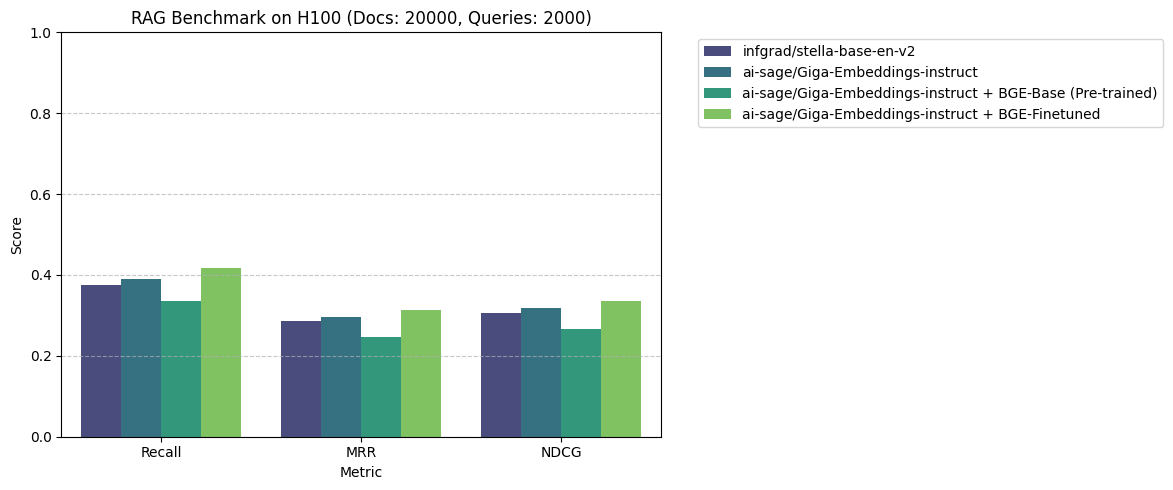

Results saved to h100_benchmark_results.csv


In [6]:
# Visualization & Reporting
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Generating Report...")

# Create DataFrame
df_data = []
for model, metrics in results.items():
    row = {"Model": model}
    row.update(metrics)
    df_data.append(row)

df = pd.DataFrame(df_data)

print("\nFinal Leaderboard:")
print(df.to_markdown(index=False, floatfmt=".4f"))

# Plotting
plt.figure(figsize=(12, 5))

# Melt for Seaborn
df_melted = df.melt(id_vars="Model", var_name="Metric", value_name="Score")

sns.barplot(data=df_melted, x="Metric", y="Score", hue="Model", palette="viridis")
plt.title(f"RAG Benchmark on H100 (Docs: {DOC_LIMIT}, Queries: {QUERY_LIMIT})")
plt.ylim(0, 1.0)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Save results
df.to_csv("h100_benchmark_results.csv", index=False)
print("Results saved to h100_benchmark_results.csv")

### **Benchmark Results Analysis**

The graph above visualizes the performance of different Retrieval & Reranking strategies on your dataset.

#### **Understanding the Models:**
*   **Stella / Giga-Embeddings:** These are the *Bi-Encoders* (Step 1). They are responsible for finding the initial top candidates from the 20,000+ documents.
    *   *Baseline*: Fast but less accurate.
    *   *Giga*: Heavy, slower, but usually deeper understanding.
*   **+ BGE-Base (Pre-trained):** This adds a *Cross-Encoder* (Step 2) to re-sort the top results. "Pre-trained" means it is using the standard model downloaded from HuggingFace, without any knowledge of your specific data.
*   **+ BGE-Finetuned:** This is the *same* Cross-Encoder, but **we trained it on your specific data** in Phase 2. It has learned the specific terminology and patterns of your questions, typically resulting in higher accuracy.

#### **Understanding the Metrics:**
*   **MRR (Mean Reciprocal Rank):** The most important metric. If the correct answer is #1, MRR is 1.0. If it's #2, MRR is 0.5. Higher is better.
*   **Recall:** Did the correct document appear *at all* in the top results?
*   **NDCG:** A measure of ranking quality that rewards placing relevant items at the top.

In [ ]:
# Phase 3: Generative Comparison (Llama 3.1 vs Qwen 2.5)
import torch
import gc
from transformers import AutoModelForCausalLM, AutoTokenizer
from sentence_transformers import util

print("Starting Phase 3: Generative RAG Comparison")

# Helper to clean memory between models
def free_gpu_memory():
    gc.collect()
    torch.cuda.empty_cache()

# Text Generation Function
def generate_rag_answer(model, tokenizer, query, context_docs):
    context_text = "\n\n".join(context_docs)

    # Chat Template: Context + Question
    # We instruct the model to use ONLY the context
    messages = [
        {"role": "system", "content": "You are a helpful assistant. Use the provided context to answer the user's question. If the answer is not in the context, say 'I don't know'."},
        {"role": "user", "content": f"Context:\n{context_text}\n\nQuestion: {query}"}
    ]

    input_text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(input_text, return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=256,
            temperature=0.1, # Deterministic-ish
            do_sample=True
        )

    generated_ids = outputs[0][inputs.input_ids.shape[1]:]
    return tokenizer.decode(generated_ids, skip_special_tokens=True)

# Define Models to Test (AWQ 4-bit versions for speed/memory)
GEN_MODELS = [
    "hugging-quants/Meta-Llama-3.1-8B-Instruct-AWQ-INT4",
    "Qwen/Qwen2.5-7B-Instruct-AWQ"
]

# We will use the 'best_model_instance' from Phase 1 to retrieve context
# Setup a small subset for generation to save time (e.g., 10 questions)
gen_subset = subset_queries[:10]
gen_results = []

for model_id in GEN_MODELS:
    print(f"\nLoading GenAI Model: {model_id}...")
    free_gpu_memory()

    try:
        tokenizer = AutoTokenizer.from_pretrained(model_id)
        llm = AutoModelForCausalLM.from_pretrained(
            model_id,
            device_map="auto",
            torch_dtype=torch.float16
        )

        print(f"   Generating answers for {len(gen_subset)} queries...")
        for q in tqdm(gen_subset, desc=f"GenAI ({model_id.split('/')[-1]})"):
            # 1. Retrieve Context using our best Retriever
            hits = best_model_instance.retrieve(q['input'], top_k=3)
            contexts = [h.payload['output'] for h in hits]

            # 2. Generate Answer
            ans = generate_rag_answer(llm, tokenizer, q['input'], contexts)

            # --- QUICK EVALUATION (Semantic Check) ---
            # Use the Embedding Model to check if Generated Answer ~= Expected Answer (Ground Truth)
            # This is much better than exact text match for Generative AI
            emb_gen = best_model_instance.encoder.encode(ans, convert_to_tensor=True, show_progress_bar=False)
            emb_ground_truth = best_model_instance.encoder.encode(q['output'], convert_to_tensor=True, show_progress_bar=False)
            
            similarity = util.cos_sim(emb_gen, emb_ground_truth).item()
            is_good = "✅" if similarity > 0.75 else "⚠️" # Soft threshold for "Good Enough"

            # 3. Store
            # Check if this question is already in results
            existing = next((item for item in gen_results if item["Question"] == q['input']), None)
            col_name = model_id.split('/')[-1] # Short name for column
            
            if existing:
                existing[col_name] = ans
                existing[f"{col_name}_Score"] = f"{similarity:.2f} {is_good}"
            else:
                gen_results.append({
                    "Question": q['input'],
                    "Ground_Truth": q['output'][:50] + "...", 
                    "Context_1": contexts[0][:200] + "...", # Preview
                    col_name: ans,
                    f"{col_name}_Score": f"{similarity:.2f} {is_good}"
                })

        del llm
        del tokenizer

    except Exception as e:
        print(f"Error running {model_id}: {e}")

free_gpu_memory()

# Show Comparison
df_gen = pd.DataFrame(gen_results)
print("\nGenerative RAG Comparison (Preview):")
print(df_gen[[col for col in df_gen.columns if "Context" not in col]].head().to_markdown(index=False))

# Save
df_gen.to_csv("generative_comparison_results.csv", index=False)
print("Saved generative results to 'generative_comparison_results.csv'")

Starting Phase 3: Generative RAG Comparison

Loading GenAI Model: hugging-quants/Meta-Llama-3.1-8B-Instruct-AWQ-INT4...


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/295 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

   Generating answers for 10 queries...


GenAI (Qwen2.5-7B-Instruct-AWQ):   0%|          | 0/10 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



Generative RAG Comparison (Preview):
| Question                                       | Qwen/Qwen2.5-7B-Instruct-AWQ                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     |
|:-----------------------------------------------|:---------------------------------------------------------------------------------------------------------

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
import shutil
import os
import glob
from tqdm.auto import tqdm

print("Zipping important folders for download/backup...")

# 1. Zip all Vector Log Folders (Qdrant Storages)
qdrant_folders = glob.glob("qdrant_storage_*")
for folder in tqdm(qdrant_folders, desc="Zipping Vector DBs"):
    if os.path.isdir(folder):
        archive_name = f"{folder}_archive"
        shutil.make_archive(archive_name, 'zip', folder)
        print(f"   -> Created: {archive_name}.zip")

# 2. Zip the Fine-tuned Model (if it exists)
if os.path.exists("models"):
    print("Zipping Fine-tuned Model...")
    shutil.make_archive("finetuned_models_backup", 'zip', "models")
    print("   -> Created: finetuned_models_backup.zip")

# 3. Zip Benchmark Results
if os.path.exists("benchmark_results") and os.path.isdir("benchmark_results"):
     print("Zipping Benchmark Results...")
     shutil.make_archive("benchmark_results_backup", 'zip', "benchmark_results")
     print("   -> Created: benchmark_results_backup.zip")

print("\nDone! You can now access these ZIP files in the file browser.")

Folder 'qdrant_storage_infgrad_stella-base-en-v2' successfully zipped to 'qdrant_storage_infgrad_stella-base-en-v2_archive.zip'. You can now download this file from the Colab file browser.
